#Week 2 Homework — Accounts Receivable Aging Report

#Part 1: Load & Explore

##Load the Data

In [32]:
import pandas as pd
import numpy as np


In [33]:
df=pd.read_csv("/content/drive/MyDrive/invoices_bd.csv")

In [34]:
df.head()

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city
0,INV-1072,Ayesha Textiles,2026-01-01,2026-03-02,75000,0.0,Unpaid,NaN,Cosmetics,Sylhet
1,INV-1025,Ayesha Textiles,2026-04-07,2026-05-07,75000,NaN,Unpaid,NaN,Cosmetics,Sylhet
2,INV-1052,Hasan Electronics,2026-02-08,2026-04-09,20000,NaN,Unpaid,NaN,Food,Rajshahi
3,INV-1163,Fatima Enterprises,2026-02-20,2026-04-06,75000,26100.0,Partial,2026-04-28,Food,Chittagong
4,INV-1098,Bilkis Garments,2026-01-15,2026-03-01,100000,100000.0,Paid,2026-02-16,Pharma,Chittagong


##Explore the dataset

In [35]:
df.shape

(205, 10)

In [41]:
df.columns

Index(['invoice_id', 'customer_name', 'invoice_date', 'due_date', 'amount_bdt',
       'paid_amount_bdt', 'status', 'payment_date', 'category', 'city'],
      dtype='object')

In [43]:
df.dtypes

,0
invoice_id,object
customer_name,object
invoice_date,object
due_date,object
amount_bdt,object
paid_amount_bdt,float64
status,object
payment_date,object
category,object
city,object


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       205 non-null    object 
 1   customer_name    203 non-null    object 
 2   invoice_date     205 non-null    object 
 3   due_date         205 non-null    object 
 4   amount_bdt       205 non-null    object 
 5   paid_amount_bdt  180 non-null    float64
 6   status           205 non-null    object 
 7   payment_date     110 non-null    object 
 8   category         205 non-null    object 
 9   city             205 non-null    object 
dtypes: float64(1), object(9)
memory usage: 16.1+ KB


In [38]:
df.describe()

,paid_amount_bdt
count,180.000000
mean,23182.777778
std,29387.997456
min,0.000000
25%,0.000000
50%,10350.000000
75%,40550.000000
max,100000.000000


Comments:
- **205** many invoices are in the dataset
- **invoice_date** ,
**due_date** ,
**payment_date**, should be converted to datetime , **amount_bdt** , should be numeric (float or int)
- Yes, there is null values in multiple columns



#Part 2: Data Cleaning

##Handle Missing Values

In [44]:
df.isnull().sum()

,0
invoice_id,0
customer_name,2
invoice_date,0
due_date,0
amount_bdt,0
paid_amount_bdt,25
status,0
payment_date,95
category,0
city,0


In [45]:
df["paid_amount_bdt"].fillna(0,inplace=True)

/tmp/ipykernel_4822/1563916440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["paid_amount_bdt"].fillna(0,inplace=True)


In [47]:
df = df.dropna(subset=["customer_name"])

In [48]:
df["customer_name"].isnull().sum()

np.int64(0)

Comments:

For null values in :
- payment_date -> keep null (unpaid invoices)
- paid_amount_bdt -> fill with 0
- customer_name -> drop

##Remove Duplicates

In [49]:
duplicates=df.duplicated(subset="invoice_id").sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 5


In [50]:
df=df.drop_duplicates(subset="invoice_id",keep="first")
print("Rows after removal:", df.shape[0])

Rows after removal: 198


In [51]:
df.shape

(198, 10)

##Fix Data Types

In [54]:
#convert to datetime
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["due_date"] = pd.to_datetime(df["due_date"], errors="coerce")
df["payment_date"] = pd.to_datetime(df["payment_date"], errors="coerce")

In [55]:
#convert to numeric
df["amount_bdt"] = pd.to_numeric(df["amount_bdt"], errors="coerce")
df["paid_amount_bdt"] = pd.to_numeric(df["paid_amount_bdt"], errors="coerce")

In [56]:
df.dtypes

,0
invoice_id,object
customer_name,object
invoice_date,datetime64[ns]
due_date,datetime64[ns]
amount_bdt,float64
paid_amount_bdt,float64
status,object
payment_date,datetime64[ns]
category,object
city,object


##Standardize Strings

In [59]:
#Clean Strings
str_cols = df.select_dtypes(include="object").columns

for col in str_cols:
    df[col] = df[col].str.strip()

df["customer_name"] = df["customer_name"].str.strip().str.title()

df["city"] = df["city"].str.strip().str.title()

In [60]:
df["city"].unique()

array(['Sylhet', 'Rajshahi', 'Chittagong', 'Dhaka'], dtype=object)

#Part 3: Build the Aging Report

In [67]:
import warnings
warnings.filterwarnings("ignore")

##Filter Unpaid Invoices

In [68]:
df_outstanding=df[df["status"].isin(["Unpaid","Partial"])]

print("Outstanding invoices:", df_outstanding.shape[0])

Outstanding invoices: 123


## Calculate Outstanding Balance

In [69]:
df_outstanding["paid_amount_bdt"]=df_outstanding["paid_amount_bdt"].fillna(0)

In [70]:
df_outstanding["outstanding_bdt"] = (
    df_outstanding["amount_bdt"] - df_outstanding["paid_amount_bdt"]
)

In [106]:
df_outstanding["outstanding_bdt"].groupby(df_outstanding["customer_name"]).sum()

,outstanding_bdt
customer_name,
Ayesha Textiles,371100.0
Bilkis Garments,449200.0
Farhan It Solutions,126200.0
Fatima Enterprises,605100.0
Hasan Electronics,133200.0
Jamal Construction,543300.0
Karim & Sons,227100.0
Nusrat Imports,295000.0
Omar Food Products,196100.0


##Calculate Days Overdue

In [71]:
today = pd.Timestamp.today().normalize()

df_outstanding["days_overdue"] = (
    today - df_outstanding["due_date"]
).dt.days


In [72]:
# Remove negative values
df_outstanding["days_overdue"] = df_outstanding["days_overdue"].clip(lower=0)

In [105]:
df_outstanding["days_overdue"].groupby(df_outstanding["customer_name"]).sum()

,days_overdue
customer_name,
Ayesha Textiles,444.0
Bilkis Garments,655.0
Farhan It Solutions,139.0
Fatima Enterprises,547.0
Hasan Electronics,371.0
Jamal Construction,408.0
Karim & Sons,241.0
Nusrat Imports,380.0
Omar Food Products,335.0


##Aging Buckets

In [73]:
conditions = [
    df_outstanding["days_overdue"] <= 30,
    df_outstanding["days_overdue"] <= 60,
    df_outstanding["days_overdue"] <= 90
]

choices = ["Current", "31-60 Days", "61-90 Days"]

df_outstanding["aging_bucket"] = np.select(
    conditions, choices, default="90+ Days"
)

# Check distribution
df_outstanding["aging_bucket"].value_counts()

,count
aging_bucket,
Current,47
61-90 Days,26
31-60 Days,25
90+ Days,25


##Pivot Report

In [74]:
aging_report = df_outstanding.pivot_table(
    index="customer_name",
    columns="aging_bucket",
    values="outstanding_bdt",
    aggfunc="sum",
    fill_value=0
)


In [75]:
# Add total
aging_report["Total"] = aging_report.sum(axis=1)

In [76]:
aging_report = aging_report.sort_values(by="Total", ascending=False)

aging_report

aging_bucket,31-60 Days,61-90 Days,90+ Days,Current,Total
customer_name,,,,,
Fatima Enterprises,156200.0,100000.0,155000.0,193900.0,605100.0
Rafiq Auto Parts,200000.0,0.0,113300.0,245000.0,558300.0
Jamal Construction,237800.0,100000.0,95500.0,110000.0,543300.0
Bilkis Garments,75000.0,3200.0,196700.0,174300.0,449200.0
Tahmina Logistics,113800.0,50000.0,0.0,225000.0,388800.0
Ayesha Textiles,15000.0,156200.0,109900.0,90000.0,371100.0
Rahim Trading Ltd,45000.0,131200.0,4000.0,175000.0,355200.0
Nusrat Imports,25000.0,55000.0,155000.0,60000.0,295000.0
Karim & Sons,0.0,95000.0,0.0,132100.0,227100.0


#📈 Part 4: Analysis & Export

##Summary Statistics

-	Print the total outstanding amount across all customers
-	Print the average outstanding amount per customer
-	Print how many customers have invoices in the "90+ Days" bucket



In [78]:
total_outstanding_amount = df_outstanding["outstanding_bdt"].sum()
print("Total Outstanding Amount:", total_outstanding_amount)

Total Outstanding Amount: 4717100.0


In [79]:
average_outstanding_amount_per_customer=df_outstanding.groupby("customer_name")["outstanding_bdt"].sum().mean()
print("Average Outstanding Amount per Customer:", average_outstanding_amount_per_customer)

Average Outstanding Amount per Customer: 314473.3333333333


In [88]:
nightyplusdays=(df_outstanding["aging_bucket"] == "90+ Days").sum()
print("Number of Customers with Invoices in the '90+ Days' Bucket:", nightyplusdays)

Number of Customers with Invoices in the '90+ Days' Bucket: 25


##City-wise Aging

In [89]:
city_outstanding = df_outstanding.groupby("city")["outstanding_bdt"].sum()

city_outstanding.sort_values(ascending=False)

,outstanding_bdt
city,
Dhaka,1980600.0
Chittagong,1733500.0
Sylhet,673700.0
Rajshahi,329300.0


Comment:

**Dhaka** has the highest outstanding amount

##Top Debtors

In [91]:
top_5_customers = aging_report.sort_values(by="Total", ascending=False).head(5)

top_5_customers

aging_bucket,31-60 Days,61-90 Days,90+ Days,Current,Total
customer_name,,,,,
Fatima Enterprises,156200.0,100000.0,155000.0,193900.0,605100.0
Rafiq Auto Parts,200000.0,0.0,113300.0,245000.0,558300.0
Jamal Construction,237800.0,100000.0,95500.0,110000.0,543300.0
Bilkis Garments,75000.0,3200.0,196700.0,174300.0,449200.0
Tahmina Logistics,113800.0,50000.0,0.0,225000.0,388800.0


##Export

In [92]:
aging_report.to_csv("aging_report.csv",index=True)

In [93]:
aging_report_df=pd.read_csv("/content/aging_report.csv")

In [94]:
aging_report_df.head(5)

,customer_name,31-60 Days,61-90 Days,90+ Days,Current,Total
0,Fatima Enterprises,156200.0,100000.0,155000.0,193900.0,605100.0
1,Rafiq Auto Parts,200000.0,0.0,113300.0,245000.0,558300.0
2,Jamal Construction,237800.0,100000.0,95500.0,110000.0,543300.0
3,Bilkis Garments,75000.0,3200.0,196700.0,174300.0,449200.0
4,Tahmina Logistics,113800.0,50000.0,0.0,225000.0,388800.0


In [95]:
df_outstanding.to_csv("outstanding_invoices.csv", index=False)

In [96]:
outstanding_invoices_df=pd.read_csv("/content/outstanding_invoices.csv")

In [97]:
outstanding_invoices_df.head(5)

,invoice_id,customer_name,invoice_date,due_date,amount_bdt,paid_amount_bdt,status,payment_date,category,city,outstanding_bdt,days_overdue,aging_bucket
0,INV-1072,Ayesha Textiles,2026-01-01,2026-03-02,75000.0,0.0,Unpaid,NaN,Cosmetics,Sylhet,75000.0,64.0,61-90 Days
1,INV-1025,Ayesha Textiles,2026-04-07,2026-05-07,75000.0,0.0,Unpaid,NaN,Cosmetics,Sylhet,75000.0,0.0,Current
2,INV-1052,Hasan Electronics,2026-02-08,2026-04-09,20000.0,0.0,Unpaid,NaN,Food,Rajshahi,20000.0,26.0,Current
3,INV-1163,Fatima Enterprises,2026-02-20,2026-04-06,75000.0,26100.0,Partial,2026-04-28,Food,Chittagong,48900.0,29.0,Current
4,INV-1085,Tahmina Logistics,2026-02-26,2026-03-28,45000.0,21200.0,Partial,2026-04-10,Electronics,Dhaka,23800.0,38.0,31-60 Days


#Bar chart

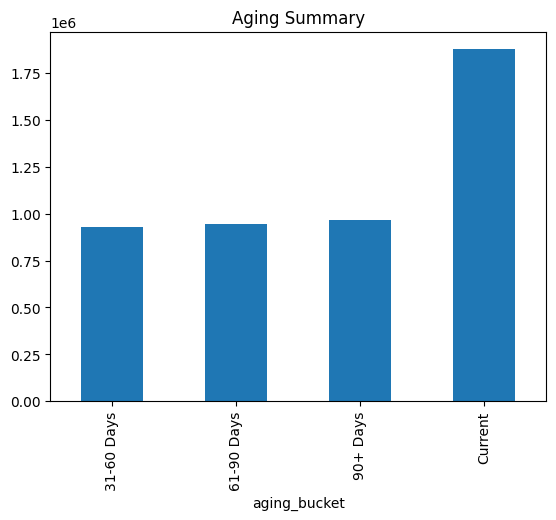

In [98]:
import matplotlib.pyplot as plt

aging_report.drop(columns="Total").sum().plot(
    kind="bar",
    title="Aging Summary"
)

plt.show()

#Weighted Avg Days

In [99]:
weighted_avg = df_outstanding.groupby("customer_name").apply(
    lambda x: (x["days_overdue"] * x["outstanding_bdt"]).sum() / x["outstanding_bdt"].sum()
)

weighted_avg

,0
customer_name,
Ayesha Textiles,58.537860
Bilkis Garments,60.499555
Farhan It Solutions,16.721870
Fatima Enterprises,58.124112
Hasan Electronics,47.340090
Jamal Construction,48.218296
Karim & Sons,45.900925
Nusrat Imports,71.033898
Omar Food Products,29.552779


#Risk Level

In [100]:
risk = aging_report.copy()

risk["90_ratio"] = risk["90+ Days"] / risk["Total"]

risk["risk_level"] = np.where(risk["90_ratio"] > 0.5, "High Risk", "Normal")

risk["risk_level"].value_counts()

,count
risk_level,
Normal,14
High Risk,1


###High Risk Customer info

In [102]:
high_risk_customers = risk[risk["risk_level"] == "High Risk"]

high_risk_customers

aging_bucket,31-60 Days,61-90 Days,90+ Days,Current,Total,90_ratio,risk_level
customer_name,,,,,,,
Nusrat Imports,25000.0,55000.0,155000.0,60000.0,295000.0,0.525424,High Risk
